In [7]:
from utils import * 
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv 

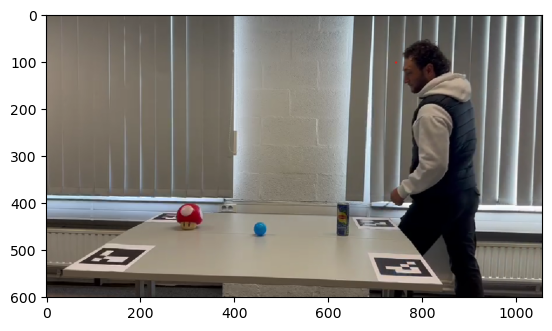

In [2]:
img =cv.imread('data/oneFrame.png')
# BGR to RGB 
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img)

In [129]:
#in_path  = "data/group_11_fixed.mp4"       
#out_path = "output/fixed_group_11_inverted.mp4"
#apply_function_to_video(in_path, out_path, lambda frame_bgr: 255 - frame_bgr)

In [130]:
#def lambda_color(frame_bgr):
#    return change_color(frame_bgr, [0,0,255],[255,0,0] ,tuning =60) # change blue to red 
#apply_function_to_video("data/group_11_fixed.mp4", "output/fixed_group_11_color_changed_t60.mp4", lambda_color)

In [131]:
#json_path = "data/annotations_group_11.json"
#load_json(json_path , False , 3) 

In [139]:
a = dict()

a["in_path"] = "data/group_11_fixed.mp4"
a["out_path"] = "output/fixed_group_11_trick2.mp4"
a["json_path"] = "data/annotations_group_11.json"

from utils import  *
def func1(frame_bgr):
    return 255 - frame_bgr
def func2(frame_bgr):
    return change_color(frame_bgr, [0,0,255],[255,0,0] ,tuning = 25)

process(a , func1, func2, func1)


JSON file loaded successfully.
JSON file loaded successfully.
JSON file loaded successfully.
trick 1 start 00:00:05
trick 2 start 00:01:14
trick 3 start 00:02:00
Saved: output/fixed_group_11_trick2.mp4
no processing from  00:00:00 to 0.0:0.0:4.9680325
trick 1 processing from 0.0:0.0:4.9680325 to 0.0:1.0:13.987007500000004
trick 2 processing from   0.0:1.0:13.987007500000004 to 0.0:1.0:59.9996575
trick 3 processing from  0.0:1.0:59.9996575 to end


In [5]:
#import utils
#dir(utils)
# to see all functions in utils.py

# now we build on top of utils.py

- we want to detect when to start the color change based on the wand

Hue value of the target color: 179
Hue value of the target color: 120


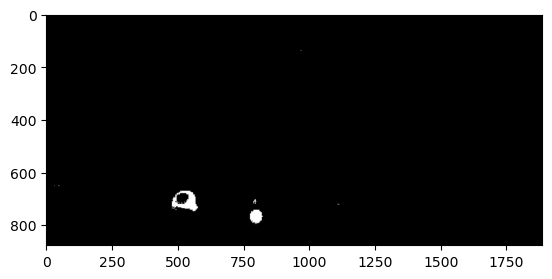

In [11]:
def detect_color(image, color, tuning=25):
    """
    Detect a specific color in an image and create a mask.

    Args:
        image (_type_): and input image in BGR format
        color (_type_): a list RGB color like [255,0,0]
        tuning (int, optional):tuning parameter. Defaults to 25.

    Returns:
        _type_: _description_
        
    """
    lower_s = 100
    lower_v = 100
    upper_s = 255
    upper_v = 255
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    color = np.uint8([[color]])
    
    hsv_color = cv2.cvtColor(color, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv_color)
    H = h[0][0]
    print("Hue value of the target color:", H)
    lower_h = max(H - tuning, 0)
    upper_h = min(H + tuning, 179)
    lower = np.array([lower_h, lower_s, lower_v])
    upper = np.array([upper_h, upper_s, upper_v])
    
    mask = cv2.inRange(hsv, lower, upper)
    return mask

img =cv.imread('data/oneFramewithWand.png')
RGB = [255,0,10]
mask1 = detect_color(img,RGB,tuning = 25) # detect red color
RGB = [0,0,255]
mask2 = detect_color(img,RGB,tuning = 25) # detect blue color
# BGR to RGB 
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
mask = cv.cvtColor(mask1+mask2, cv.COLOR_BGR2RGB)
#plt.imshow(img)
plt.imshow(mask)

- here what I did is just to detect the red , then detect the blue then sum the two mask 
- here it is interesting to see that we still have the mushroom appearing in the mask we just need to discriminate red color by computing some distances between blue pixel and red pixel and take the nearest object 

In [50]:
# check that the masks are binary
np.isin(mask1,[0,255]).all() , np.isin(mask2,[0,255]).all()

(np.True_, np.True_)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.89187649641186e-17..254.99999999999997].


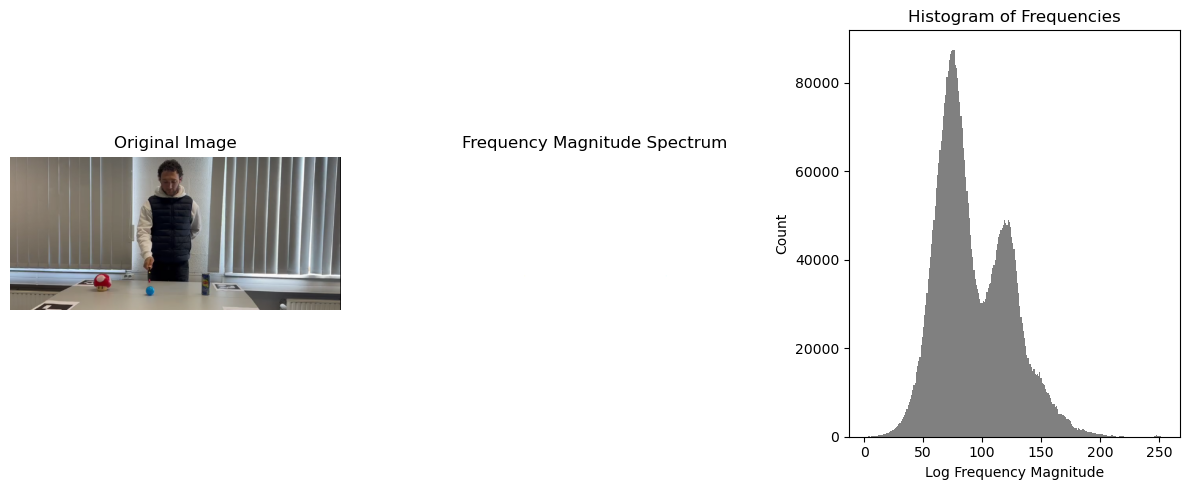

In [64]:
# do we need to preprocess the img ?
#lets try to look at the frequency domain
import cv2
import numpy as np
import matplotlib.pyplot as plt


# --- Compute 2D FFT and shift the DC component to the center ---
F = np.fft.fft2(img)
Fshift = np.fft.fftshift(F)

# --- Compute magnitude spectrum (log scale for visibility) ---
magnitude_spectrum = np.log1p(np.abs(Fshift))
magnitude_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX)

# --- Visualization ---
plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

# Frequency magnitude spectrum
plt.subplot(1, 3, 2)
plt.title("Frequency Magnitude Spectrum")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

# Histogram of the magnitude spectrum
plt.subplot(1, 3, 3)
plt.title("Histogram of Frequencies")
plt.hist(magnitude_spectrum.ravel(), bins=256, color='gray')
plt.xlabel("Log Frequency Magnitude")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



In [19]:
img =cv.imread('data/oneFramewithWand.png')
import cv2
import numpy as np
import matplotlib.pyplot as plt
RGB = [255,0,10]
mask1 = detect_color(img,RGB,tuning = 25)
mask1_u8 = (mask1/255).astype(np.uint8)
RGB = [0,0,255]
mask2 = detect_color(img,RGB,tuning = 25)
mask2_u8 = (mask2/255).astype(np.uint8)


mask1.max(), mask2.max()



Hue value of the target color: 179
Hue value of the target color: 120


(np.uint8(255), np.uint8(255))

In [20]:
def centroid(mask):
    return [int(np.mean(np.where(mask==1)[0])),int(np.mean(np.where(mask==1)[1]))]

centroid(mask1_u8), centroid(mask2_u8)


([710, 542], [767, 794])

255


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(877, 1887), dtype=uint8)

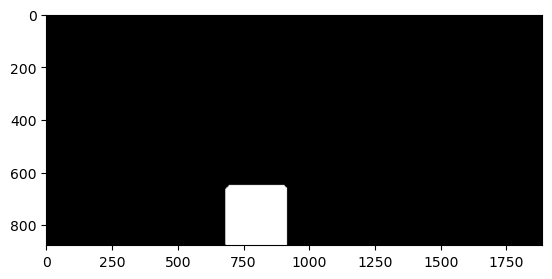

In [56]:
s = 10
SE= cv.getStructuringElement(cv.MORPH_RECT,(s,s))
eroded_mask2 = cv.erode(mask2,SE)
s = 200
SE= cv.getStructuringElement(cv.MORPH_RECT,(s,s))
dilated_mask = cv.dilate(eroded_mask2,SE)
dilated_mask_1 = cv.cvtColor(dilated_mask, cv.COLOR_BGR2RGB)
plt.imshow(dilated_mask_1 )
print(np.max(dilated_mask))
dilated_mask

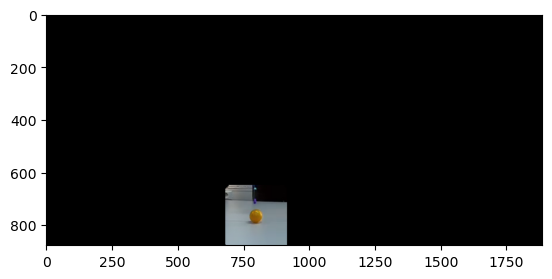

In [57]:
# now we first dilate the blue ball 
# then we  use it to mark a region of interest 
img =cv.imread('data/oneFramewithWand.png')
new_image = cv.bitwise_and(img , img , mask = dilated_mask)
plt.imshow(new_image)


Hue value of the target color: 179


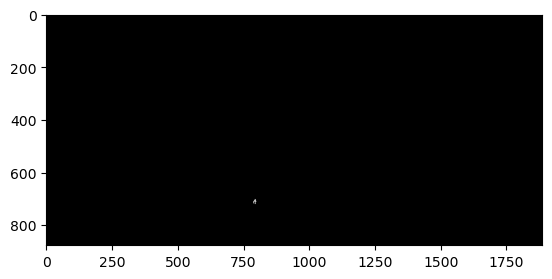

In [58]:
RGB = [255,0,10]
mask3 = detect_color(new_image,RGB,tuning = 25)
mask3 = cv.cvtColor(mask3, cv.COLOR_BGR2RGB)
plt.imshow(mask3)

In [69]:
def roi(img  , RGB ,s_erod , s_dil):
    """
    Create a region of interest mask based
    
    s_erod: size for erosion
    s_dil: size for dilation
    img : input image
    RGB : color to detect
    """
    
    mask = detect_color(img,RGB,tuning = 25)
    # we erode first to remove noise (small white regions detected by mistake)
    kernel_erod = (s_erod , s_erod)
    SE= cv.getStructuringElement(cv.MORPH_RECT,kernel_erod)
    eroded_mask = cv.erode(mask,SE)
    
    #then we dilate to get the full region of interest around the detected object
    
    kernel_dil = (s_dil , s_dil)
    SE= cv.getStructuringElement(cv.MORPH_RECT,kernel_dil)
    
    dilated_mask = cv.dilate(eroded_mask,SE)
    
    new_image = cv.bitwise_and(img , img , mask = dilated_mask)
    
    #for visualization
    plt.imshow(cv.cvtColor(new_image, cv.COLOR_BGR2RGB))
    return new_image

Hue value of the target color: 120
Hue value of the target color: 179


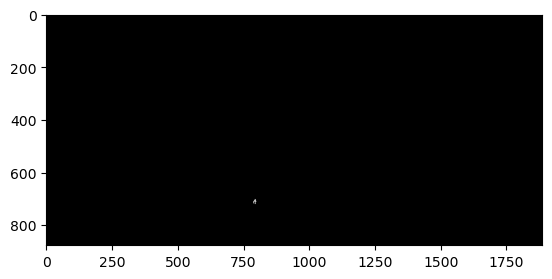

In [74]:
RGB = [0,0,255]
new_image = roi(img , RGB , s_erod=10 , s_dil=200)
RGB = [255,0,10]
mask3 = detect_color(new_image,RGB,tuning = 25)
mask3 = cv.cvtColor(mask3, cv.COLOR_BGR2RGB)
plt.imshow(mask3)